Overview: The purpose of this task is to predict energy consumption using historical data from transmission system operator. The dataset contains 6 years of hourly electricity consumption data and represents a univariate time series with seasonal patterns. My approach to this is using machine learning techniques and develop data driven model for hourly forecast of future energy demand accurately.

Breaking down the scenarion of electricity consumption prediction 
1. Understanding univariate time series forecasting
Univariate time series means you've a single variable, electricity consumption, over time. 
2. Time series data are ordered dependent.
3. A time series data notes the observation of particular individual/entity at different time points.
4. A panel or longitudinal data refers to datasets with repeated observations of same subjects (individuals, firms, countries) over time, combining cross-sectional and time-series data.

Steps to analyze time series analysis
1. Plotting the data and analyzing it to extract meaningful information
2. Study the past behaviour 
3. Identify underlying patterns and trends
4. Use past data for forecasting


**Trend is any upward or downward movement
 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/Energy prediction.csv')
df.head(10) #used to check top 5 values

,Start time UTC,End time UTC,Electricity consumption (MWh)
0,12/31/2015 21:00,12/31/2015 22:00,10800
1,12/31/2015 22:00,12/31/2015 23:00,10431
2,12/31/2015 23:00,1/1/2016 0:00,10005
3,1/1/2016 0:00,1/1/2016 1:00,9722
4,1/1/2016 1:00,1/1/2016 2:00,9599
5,1/1/2016 2:00,1/1/2016 3:00,9524
6,1/1/2016 3:00,1/1/2016 4:00,9601
7,1/1/2016 4:00,1/1/2016 5:00,9793
8,1/1/2016 5:00,1/1/2016 6:00,9815
9,1/1/2016 6:00,1/1/2016 7:00,9998


In [2]:
df.tail(10) #Used to check bottom 5 values

,Start time UTC,End time UTC,Electricity consumption (MWh)
52956,12/31/2021 11:00,12/31/2021 12:00,11102
52957,12/31/2021 12:00,12/31/2021 13:00,11103
52958,12/31/2021 13:00,12/31/2021 14:00,11314
52959,12/31/2021 14:00,12/31/2021 15:00,11552
52960,12/31/2021 15:00,12/31/2021 16:00,11575
52961,12/31/2021 16:00,12/31/2021 17:00,11447
52962,12/31/2021 17:00,12/31/2021 18:00,11237
52963,12/31/2021 18:00,12/31/2021 19:00,10914
52964,12/31/2021 19:00,12/31/2021 20:00,10599
52965,12/31/2021 20:00,12/31/2021 21:00,10812


In [3]:
df.sample(10)

,Start time UTC,End time UTC,Electricity consumption (MWh)
34444,11/22/2019 4:00,11/22/2019 5:00,10012
25875,12/13/2018 12:00,12/13/2018 13:00,12075
39685,6/27/2020 0:00,6/27/2020 1:00,6942
8678,12/26/2016 15:00,12/26/2016 16:00,9529
52735,12/22/2021 6:00,12/22/2021 7:00,13242
42212,10/9/2020 19:00,10/9/2020 20:00,8379
39097,6/2/2020 12:00,6/2/2020 13:00,7894
33864,10/28/2019 20:00,10/28/2019 21:00,10214
15744,10/17/2017 6:00,10/17/2017 7:00,9845
23005,8/15/2018 22:00,8/15/2018 23:00,7838


In [4]:
df.shape

(52966, 3)

Total no. of extra hours entry = 52966 - 52608 = 358

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52966 entries, 0 to 52965
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Start time UTC                 52966 non-null  object
 1   End time UTC                   52966 non-null  object
 2   Electricity consumption (MWh)  52966 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


Data contains following information on:

1. Hourly electricity consumption (MWh)
2. Univariate time series
3. Timestamped sequential data
4. Strong seasonality
5. It is possible that data might have missing values, outliers, etc.

In [6]:
df.describe()

,Electricity consumption (MWh)
count,52966.000000
mean,9488.750519
std,1576.241673
min,5341.000000
25%,8322.000000
50%,9277.000000
75%,10602.000000
max,15105.000000


When received for analysis, data is often in a raw or dirty state and not ready for data mining algorithm. Preparing data for mining includes several types of cleaning and pre-processing. Data preparation tasks focus on determinig what data is available to analyze and transforming that data to be easily analyzed.
Data preparation can include:
1. Handling missing values, duplicate data
2. Dealing with outliers and errorneous data
3. Feature Engineering

In [7]:
df.isna().sum() #used to check for missing values

,0
Start time UTC,0
End time UTC,0
Electricity consumption (MWh),0


In [8]:
df.duplicated().sum() #used to check for duplicates in data

np.int64(0)

We've previously figured out there are 358 extra rows in the data set. What could be reason?
1. Duplicate time stamp - Same hour recorded more than once
2. Missing time continuity - Some timestamp might not increase strictly by 1 hour
3. DST duplication but UTC does not have DST

Step -1 Identify the problem

In [9]:
df['Start time UTC'] = pd.to_datetime(df['Start time UTC'])
df = df.sort_values('Start time UTC')

In [10]:
duplicates = df[df.duplicated(subset='Start time UTC', keep=False)]
print(len(duplicates)) #Check for dupliicates in timestamp

0


If duplicates = 0, then verify time period boundary

In [11]:
print("Min time:", df['Start time UTC'].min())
print("Max time:", df['Start time UTC'].max())

Min time: 2015-12-31 21:00:00
Max time: 2021-12-31 20:00:00


In [12]:
#Compute expected hours from actual min to max
expected_range = pd.date_range(
    start=df['Start time UTC'].min(),
    end=df['Start time UTC'].max(),
    freq='H'
)

print("Expected hours:", len(expected_range))
print("Actual rows:", len(df))

Expected hours: 52608
Actual rows: 52966


len(expected_range) < len(df)
→ There are timestamps outside the continuous range.

In [13]:
#Check time difference structure
df = df.sort_values('Start time UTC')
df['diff'] = df['Start time UTC'].diff()

df['diff'].value_counts()

,count
diff,
0 days 01:00:00,51718
0 days 00:55:00,513
0 days 00:05:00,377
0 days 01:05:00,156
0 days 00:50:00,32
0 days 00:10:00,28
0 days 00:35:00,23
0 days 02:00:00,21
0 days 00:25:00,18


Cross check

In [14]:
vc = df['diff'].value_counts()

total_hours = 0

for delta, count in vc.items():
    total_hours += (delta.total_seconds() / 3600) * count

print("Computed total hours:", total_hours)

Computed total hours: 52606.999999999985


In [15]:
(df['Start time UTC'].max() - df['Start time UTC'].min()).total_seconds() / 3600

52607.0

In [16]:
df.sample(3)

,Start time UTC,End time UTC,Electricity consumption (MWh),diff
41063,2020-08-23 10:00:00,8/23/2020 11:00,7241,0 days 01:00:00
11220,2017-04-11 08:00:00,4/11/2017 9:00,10158,0 days 01:00:00
24210,2018-10-05 03:00:00,10/5/2018 4:00,9977,0 days 01:00:00


In [17]:
df['diff'].isna().sum()

np.int64(1)

In [18]:
df = df.drop('diff', axis=1)

Outliers and errorneous data
1. The identification of outliers and errorneous data is accomplished through the use of descriptive statistics and visualization. An outlier is a value that is extreme or "lies outside" (is much smaller and larger than the most of) the other values in a set of data.
2. They're unusual data points that differ significantly from rest of the samples. They can occur due to an error in data collection process or they are just legitimate data points and represent natural variation.
3. Often domain knowledge is required to determine if an outlier is an error, or just an extreme but valid value.
4. Once outliers are identified, one common approach is to create a second dataset without the outliers and build data mining model on both datasets.
5. If the conclusions are the same, the outliers can simply remain in the data. Otherwise, further effort is needed to identify cause of the outliers.

Data have start time UTC (object); End time UTC (Object) and electricityconsumption (MWh)

I want visual outlier detection so:
1. Convert time columns properly
2. Use boxplot to see extreme values & distribution
3. Use time series line plot to see behavioural spikes
4. Minimal clutter
5. Highlight outliers

Step1: Prepare the data

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert datetime columns
df['Start time UTC'] = pd.to_datetime(df['Start time UTC'])
df['End time UTC'] = pd.to_datetime(df['End time UTC'])

# Sort by time (critical for time series storytelling)
df = df.sort_values('Start time UTC')

Step2: Boxplot (See distribution and outliers)

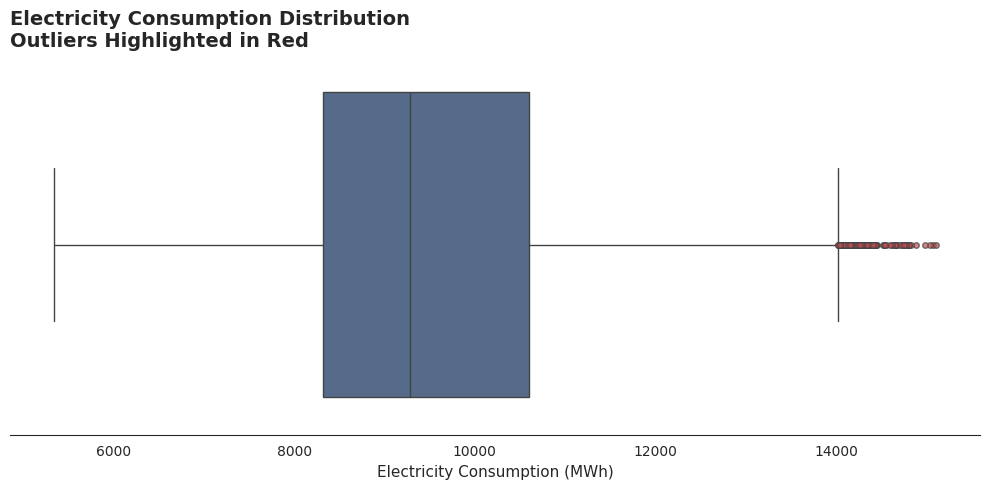

In [20]:
# Styling
sns.set_style("white")
plt.figure(figsize=(10, 5))

# Blue-grey color palette
box_color = "#4C6A92"
outlier_color = "#C44E52"

sns.boxplot(
    x=df['Electricity consumption (MWh)'],
    color=box_color,
    flierprops=dict(marker='o',
                    markerfacecolor=outlier_color,
                    markersize=4,
                    linestyle='none',
                    alpha=0.7)
)

plt.title("Electricity Consumption Distribution\nOutliers Highlighted in Red",
          fontsize=14, weight='bold', loc='left')

plt.xlabel("Electricity Consumption (MWh)", fontsize=11)
plt.yticks([])
sns.despine(left=True)
plt.tight_layout()

plt.show()

3. Time Series with Highlighted Outliers



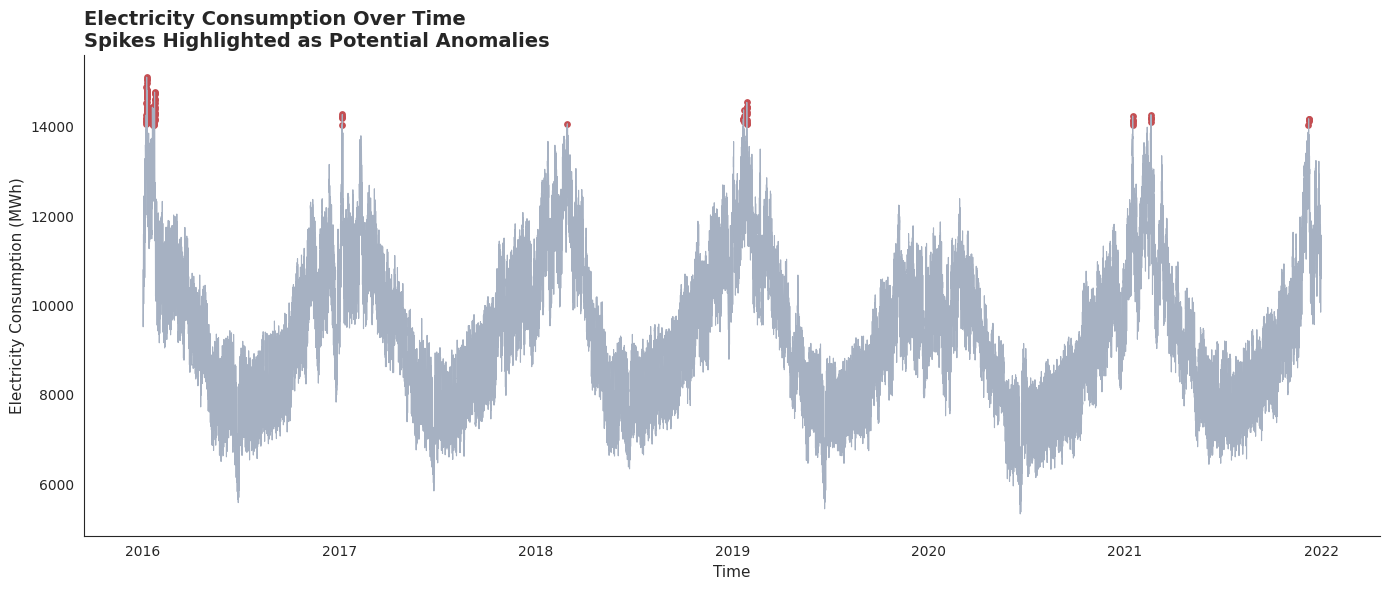

In [21]:
# Calculate IQR for outlier detection
Q1 = df['Electricity consumption (MWh)'].quantile(0.25)
Q3 = df['Electricity consumption (MWh)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag outliers
df['Outlier'] = (
    (df['Electricity consumption (MWh)'] < lower_bound) |
    (df['Electricity consumption (MWh)'] > upper_bound)
)

# Plot
plt.figure(figsize=(14, 6))

# Base line (muted)
plt.plot(df['Start time UTC'],
         df['Electricity consumption (MWh)'],
         color="#A6B1C2",
         linewidth=0.8)

# Highlight outliers
plt.scatter(
    df[df['Outlier']]['Start time UTC'],
    df[df['Outlier']]['Electricity consumption (MWh)'],
    color="#C44E52",
    s=15
)

plt.title("Electricity Consumption Over Time\nSpikes Highlighted as Potential Anomalies",
          fontsize=14, weight='bold', loc='left')

plt.xlabel("Time", fontsize=11)
plt.ylabel("Electricity Consumption (MWh)", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

Seasonality is present

Mild trend in batches

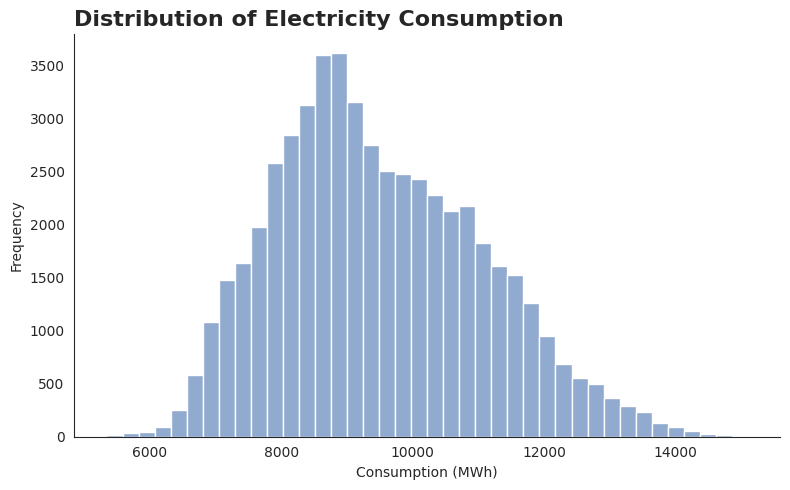

In [22]:
# Sort by time
df = df.sort_values('Start time UTC')

# Rename for simplicity
df.rename(columns={'Electricity consumption (MWh)': 'consumption'}, inplace=True)

# -----------------------------
# Clean aesthetic settings
# -----------------------------
sns.set_style("white")

# -----------------------------
# 3️⃣ Distribution View
# -----------------------------
plt.figure(figsize=(8,5))

sns.histplot(df['consumption'], bins=40,
             color="#6C8EBF", edgecolor="white")

plt.title("Distribution of Electricity Consumption", fontsize=16, weight='bold', loc='left')
plt.xlabel("Consumption (MWh)")
plt.ylabel("Frequency")

sns.despine()
plt.tight_layout()
plt.show()

Key insights till now:

This is regression/time-series data, not classification.

Single peak (unimodal)

Roughly bell-shaped

Slight right skew (longer tail toward high consumption values)

Most values concentrated between ~7500 and ~11000 MWh



In [23]:
df.head(3)

,Start time UTC,End time UTC,consumption,Outlier
0,2015-12-31 21:00:00,2015-12-31 22:00:00,10800,False
1,2015-12-31 22:00:00,2015-12-31 23:00:00,10431,False
2,2015-12-31 23:00:00,2016-01-01 00:00:00,10005,False


In [24]:
#Create another data ready to dowload as csv removing all outliers and at last drop outlers from column
print(df['Outlier'].dtype)

df['Outlier'] = df['Outlier'].astype(bool)
df.to_csv("energy_consumption_original.csv", index=False)

df_clean = df[df['Outlier'] == False].copy()
df_clean.to_csv("energy_consumption_clean.csv", index = False)

#Check
print("Original Shape:", df.shape)
print("Clean shape:", df_clean.shape)
print("Outliers removed:", df['Outlier'].sum()) #To ensure no data mismatch


bool
Original Shape: (52966, 4)
Clean shape: (52840, 4)
Outliers removed: 126


Objective: Forecast future hourly electricity consumption using historical data. 

Given is a supervised time series regression problem 

Target variable => Yt = Electricity consumption at time t

The machine learning pipeline flow follows a logical structure:
1. Data Loading 
2. Data preprocessing
3. Exploratory Data Analysis
4. Feature Engineering
5. Train-validation-test split
6. Baseline Models
7. Advanced Models
8. Model Evaluation
9. Model Comparison
10. Business interpretation

Data Preprocessing: 

1. For the given dataset timestamp should be first converted to datetime format and sorted chronologically. 
2. Missing values can be filled using forward fill, backward fill, linear interpolation. As forward fill works best for short hourly gaps because electricity demand typically changes gradually.
3. Outlier detection. Remove outliers because ARIMA is sensitive to extreme values; Neural network may overfit spikes; tree models may distort splits. Removal must be domain aware.

Exploratory Data Analysis (EDA): 

1. Seasonal decomposition breaks a time series into three or four different components: Trend, seasonality, cycle and residual.
2. Concept of stationarity: A stationary time series has statistical properties - mean, variance, and autocorrelation - that remains constant over time making it's behavior independent of the observation time.

Since this is a single observation for each random variable Y(t), inference is too complicated if distribution change for all values of t. So, it's very difficult to identify a joint distribution. Thus, a simplification is required which is called stationarity.

3. Autocorrelation Function (ACF): It gives the correlation between value at time t and s for a time series.

PACF (Partial autocorrelation function): measures correlation between a time series Y(t) and Y(t-k) after removing the effect of intermediate lag Y(t-1),....,Y(t-k+1).

ARIMA stands for AutoRegressive Integrated Moving Average. It is popular statistical analysis model used for time series forecasting, which predicts future values based on past data. The model combines three components - Autoregression (AR), Integration, and moving average (MA). 

Feature Engineering: 

It's the process of using domain knowledge and data transformation techniques to create new input features or modify existing ones to make machine learning algorithm work properly.

- Lag Features are created by shifting time-series data to create new features (e.g. mapping demand at time t-1 as an input feature for predicting demand at time t).


- suitable for converting a purely sequential time series into a row-based format suitable for traditional machine learning models

- Rolling Statistics analyze time-series data by calculating metrics—like mean, sum, or standard deviation—across a fixed-size, shifting window of consecutive data points. This helps to capture short term trend and detect volatility.

- Feature extraction of hours, day of week, month, quater. This is cyclically encoded to preserve circular continuity.

Model Selection:

To choose an appropriate model algorithm for a dataset balancing accuracy, complexity and interpretability.

- Naive Mean

- Seasonal Naive

- ARIMA (AutoRegressive Integrated Moving Average)

1. Best for: Linear trends, seasonal patterns
2. Advantages: Interpretable, fast, minimal data needed
3. Disadvantages: Assumes stationarity, limited to linear relationships

- Prophet

1. Best for: Business time series with clear seasonality
2. Advantages: Handles missing data, holidays, trend changes
3. Disadvantages: Less suitable for complex patterns

- LSTM

1. Best for: Long-term dependencies, non-linear patterns
2. Advantages: Captures complex temporal dependencies
3. Disadvantages: Requires more data, harder to tune

- XGBoost/Light GBM

1. Best for: Feature-rich time series
2. Advantages: Fast, handles non-linearity, feature importance
3. Disadvantages: Needs feature engineering

Model Training:

The process of teaching a machine learning model to optimize performance on a training dataset of sample tasks relevant to model's eventual use cases. The cleaned data is split into train-validation-test. Training data is used for developing model and test data is used for reference.

Model Evaluation:

To test the accuracy, the test data is used. This helps to identify appropriate algorithm based on predicted outcomes. There are many evaluation metrics:
1. MAE (Mean Absolute Error)
2. RMSE (Root Mean Squared Error)
3. MAPE (Mean Absolute Percentage Error) - best for business context
4. SMAPE (Symmetric MAPE)
5. Directional Accuracy (for trend prediction)

Improvement in performance


               ELECTRICITY CONSUMPTION FORECASTING
                    COMPLETE ML PIPELINE
[PHASE 1] Loading Data...
✓ Data loaded successfully!
  Shape: (52966, 2)
  Date range: 2015-12-31 21:00:00+00:00 to 2021-12-31 20:00:00+00:00
  Duration: 2191 days
  Missing values: 0

  Data unit: MWh (Megawatt-hour)
  Frequency: Hourly

[PHASE 1] Data Inspection:

First 10 rows:
                  timestamp  consumption
0 2015-12-31 21:00:00+00:00        10800
1 2015-12-31 22:00:00+00:00        10431
2 2015-12-31 23:00:00+00:00        10005
3 2016-01-01 00:00:00+00:00         9722
4 2016-01-01 01:00:00+00:00         9599
5 2016-01-01 02:00:00+00:00         9524
6 2016-01-01 03:00:00+00:00         9601
7 2016-01-01 04:00:00+00:00         9793
8 2016-01-01 05:00:00+00:00         9815
9 2016-01-01 06:00:00+00:00         9998

Last 10 rows:
                      timestamp  consumption
52956 2021-12-31 11:00:00+00:00        11102
52957 2021-12-31 12:00:00+00:00        11103
52958 2021-12-31 13:00:

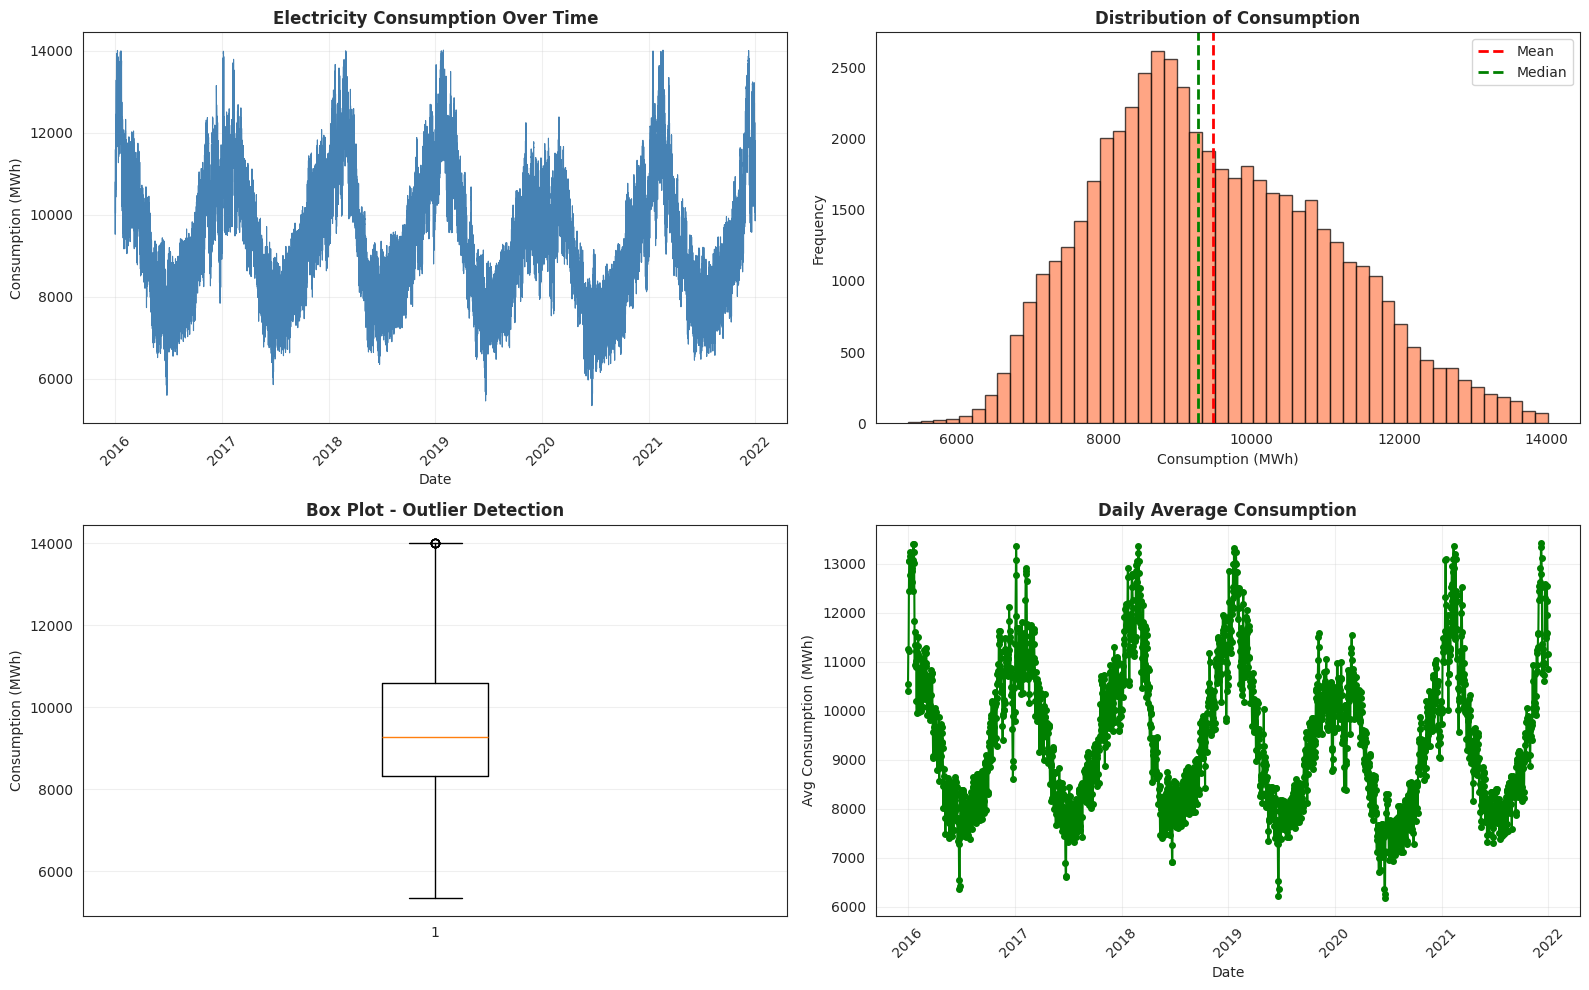

✓ Saved: 01_raw_data_analysis.png

[PHASE 3] Seasonal Decomposition (period=24 hours)...


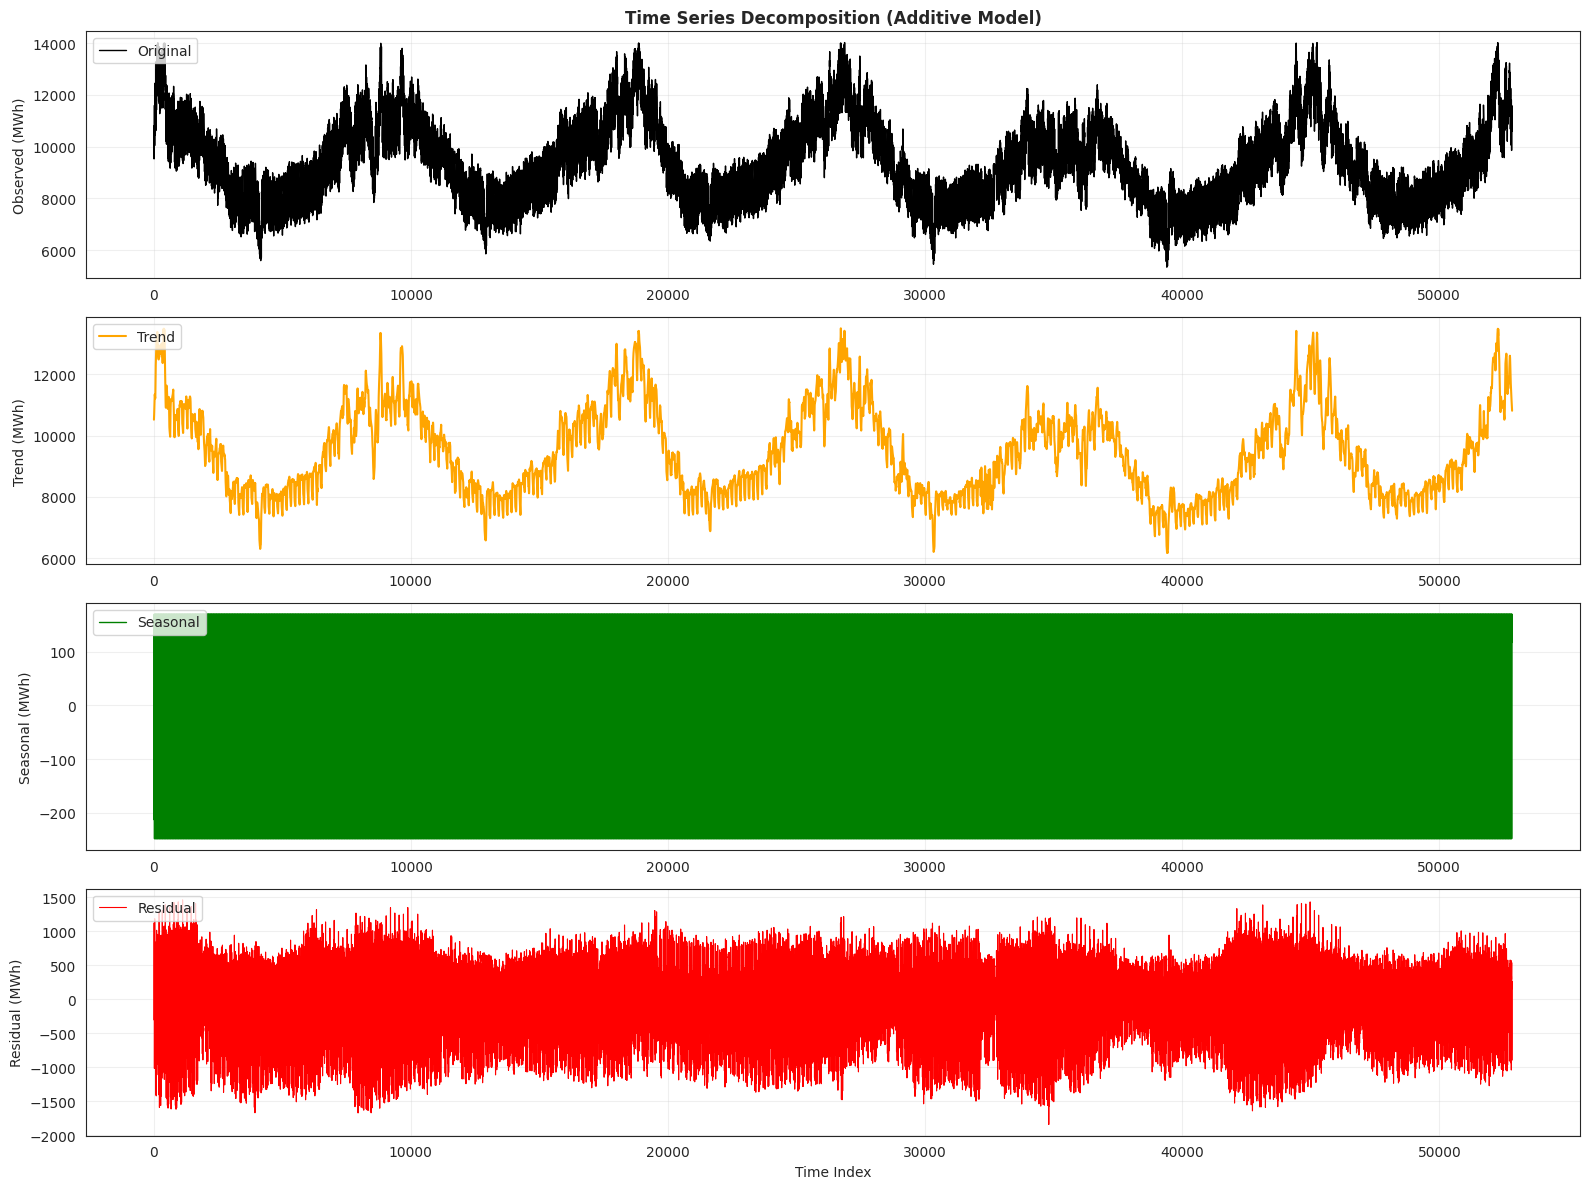

✓ Saved: 02_seasonal_decomposition.png

[PHASE 3] Stationarity Test (Augmented Dickey-Fuller)...

ADF Test Results:
  ADF Statistic: -6.164836
  P-value: 0.000000
  Number of lags used: 58
  Number of observations: 52781

  Critical Values:
    1%: -3.430
    5%: -2.862
    10%: -2.567

✓ Result: Time series IS STATIONARY (p-value ≤ 0.05)
  → No differencing needed for ARIMA

[PHASE 3] ACF/PACF Analysis (for ARIMA parameter selection)...


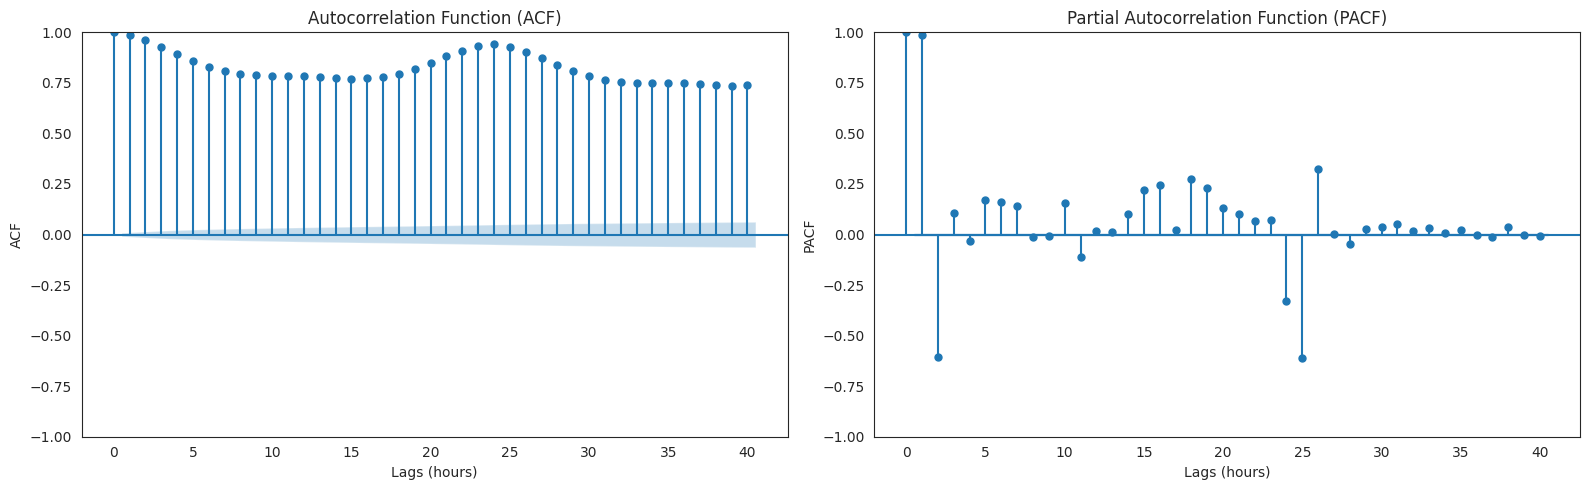

✓ Saved: 03_acf_pacf.png

[PHASE 4] Creating Lag Features...
  ✓ Created lag1 (consumption 1 hours ago)
  ✓ Created lag3 (consumption 3 hours ago)
  ✓ Created lag6 (consumption 6 hours ago)
  ✓ Created lag12 (consumption 12 hours ago)
  ✓ Created lag24 (consumption 24 hours ago)
  ✓ Created lag48 (consumption 48 hours ago)
  ✓ Created lag168 (consumption 168 hours ago)

[PHASE 4] Creating Rolling Features...
  ✓ Created rolling features for window=3h
  ✓ Created rolling features for window=6h
  ✓ Created rolling features for window=12h
  ✓ Created rolling features for window=24h

[PHASE 4] Creating Temporal Features...
  ✓ Created temporal features

[PHASE 4] Visualizing Engineered Features...


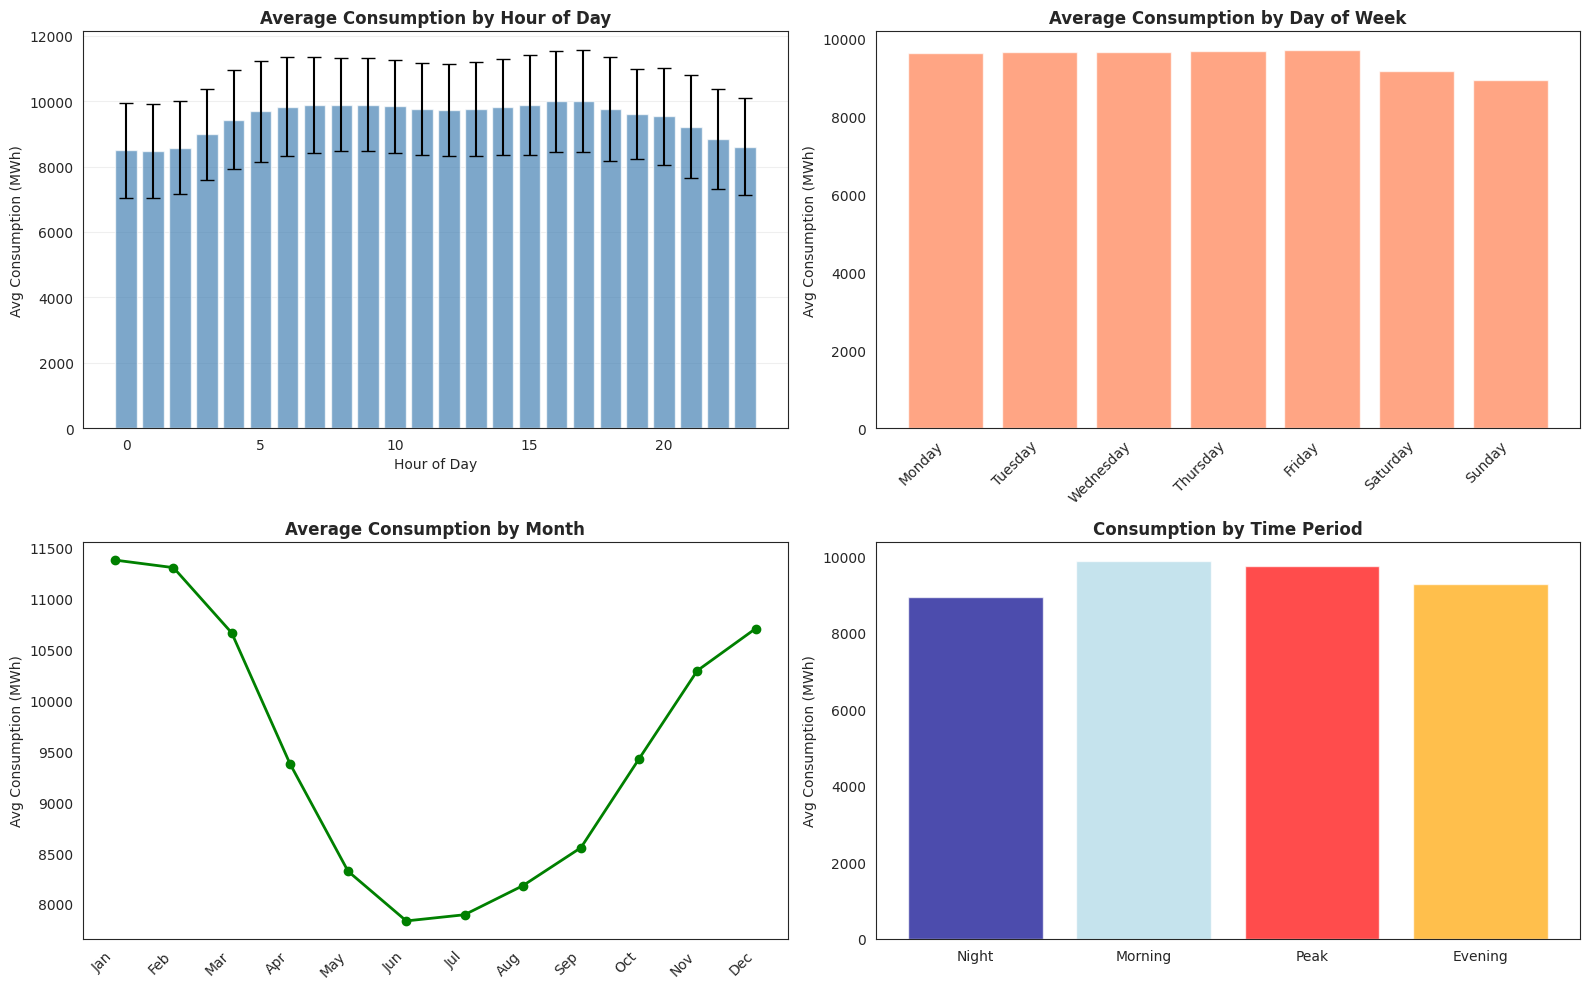

✓ Saved: 04_feature_analysis.png

[PHASE 5] Preparing Data for Modeling...
  Rows removed (due to NaN): 168
  Rows remaining: 52672

Data Split Summary:
  Train: 36870 samples (70.0%)
  Val:   7900 samples (15.0%)
  Test:  7902 samples (15.0%)

[PHASE 6] Naive Baseline Forecast...
  Naive MAE: 1310.05 MWh
  Naive RMSE: 1616.34 MWh
  Naive MAPE: 0.1388%

[PHASE 6] Seasonal Naive Baseline (24-hour period)...
  Seasonal Naive MAE: 366.24 MWh
  Seasonal Naive RMSE: 523.33 MWh
  Seasonal Naive MAPE: 0.0378%

[PHASE 7] ARIMA Model ARIMA(1, 1, 1)...
  ARIMA(1, 1, 1) MAE: 2146.20 MWh
  ARIMA(1, 1, 1) RMSE: 2436.03 MWh
  ARIMA(1, 1, 1) MAPE: 0.2509%

[PHASE 8] Prophet Model...
✗ Prophet Error: Column ds has timezone specified, which is not supported. Remove timezone.

[PHASE 9] LSTM Deep Learning Model (lookback=24h)...
  X_train shape: (36846, 24, 1), y_train shape: (36846, 1)
  X_test shape: (7878, 24, 1), y_test shape: (7878, 1)

LSTM Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 0.0205 - mae: 0.0986 - val_loss: 0.0021 - val_mae: 0.0351
Epoch 2/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0032 - mae: 0.0438 - val_loss: 0.0026 - val_mae: 0.0395
Epoch 3/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0023 - mae: 0.0360 - val_loss: 0.0023 - val_mae: 0.0385
Epoch 4/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0016 - mae: 0.0306 - val_loss: 0.0021 - val_mae: 0.0379
Epoch 5/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0013 - mae: 0.0273 - val_loss: 0.0032 - val_mae: 0.0471
Epoch 6/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0011 - mae: 0.0253 - val_loss: 0.0022 - val_mae: 0.0395

  LSTM MAE: 283.39 MWh
  LSTM RMSE: 372.47 MWh
  LSTM MAPE: 0.0301%


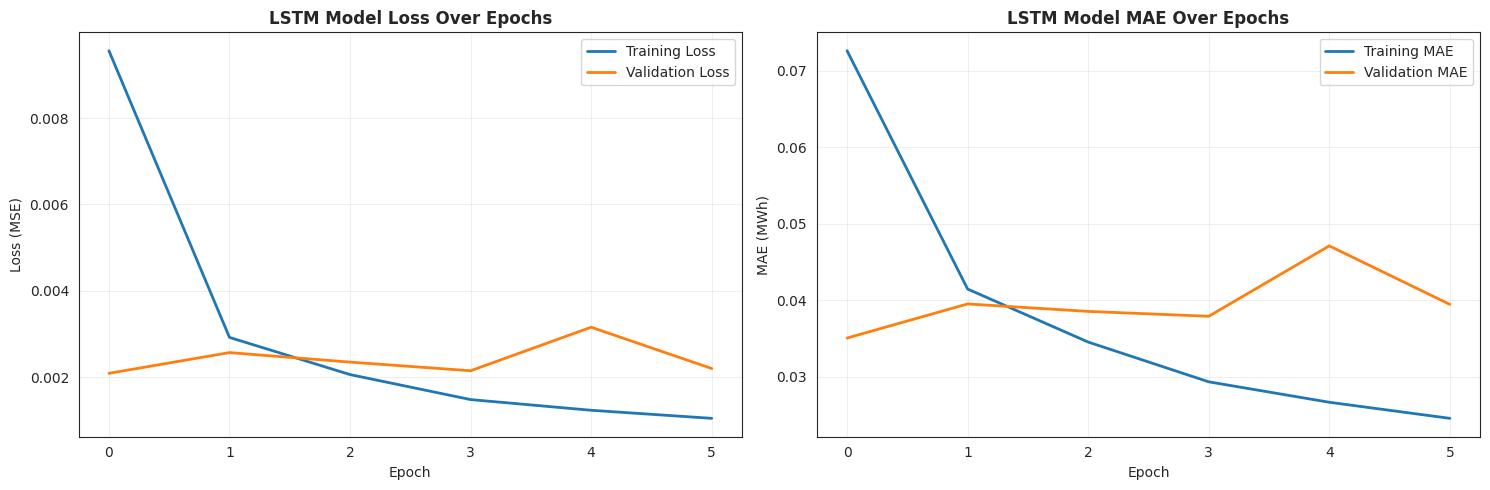

✓ Saved: 06_lstm_training_history.png

[PHASE 10] XGBoost Model...
  Features used: 37
✗ XGBoost Error: XGBModel.fit() got an unexpected keyword argument 'early_stopping_rounds'

[PHASE 10] LightGBM Model...
✗ LightGBM Error: LGBMRegressor.fit() got an unexpected keyword argument 'early_stopping_rounds'

[PHASE 11] MODEL COMPARISON...

Model Performance Ranking (sorted by MAE):

Model                MAE (MWh)       RMSE (MWh)      MAPE (%)       
------------------------------------------------------------------------------------------
LSTM                 283.39          372.47          0.0301         
Seasonal Naive       366.24          523.33          0.0378         
Naive Baseline       1310.05         1616.34         0.1388         
ARIMA                2146.20         2436.03         0.2509         


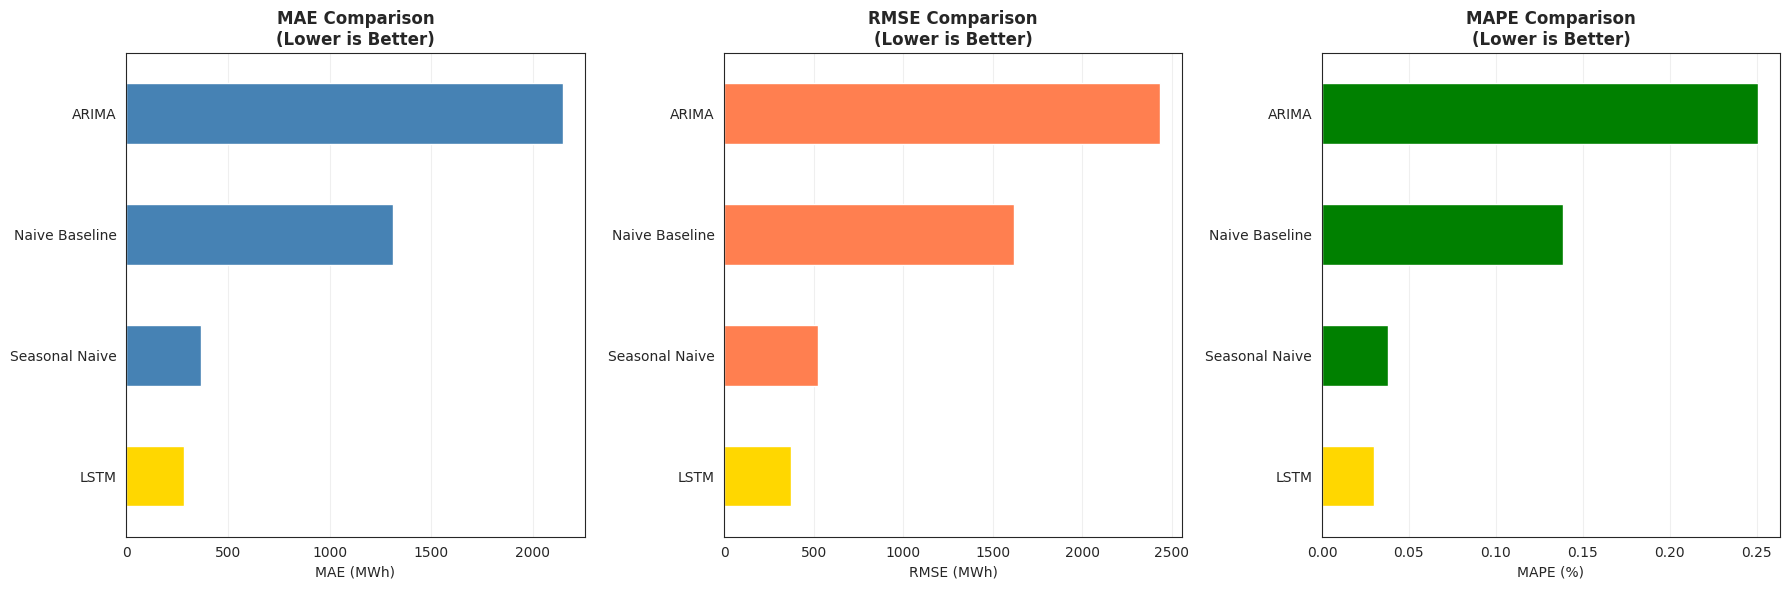

✓ Saved: 08_model_comparison.png

[PHASE 12] Visualizing Predictions...


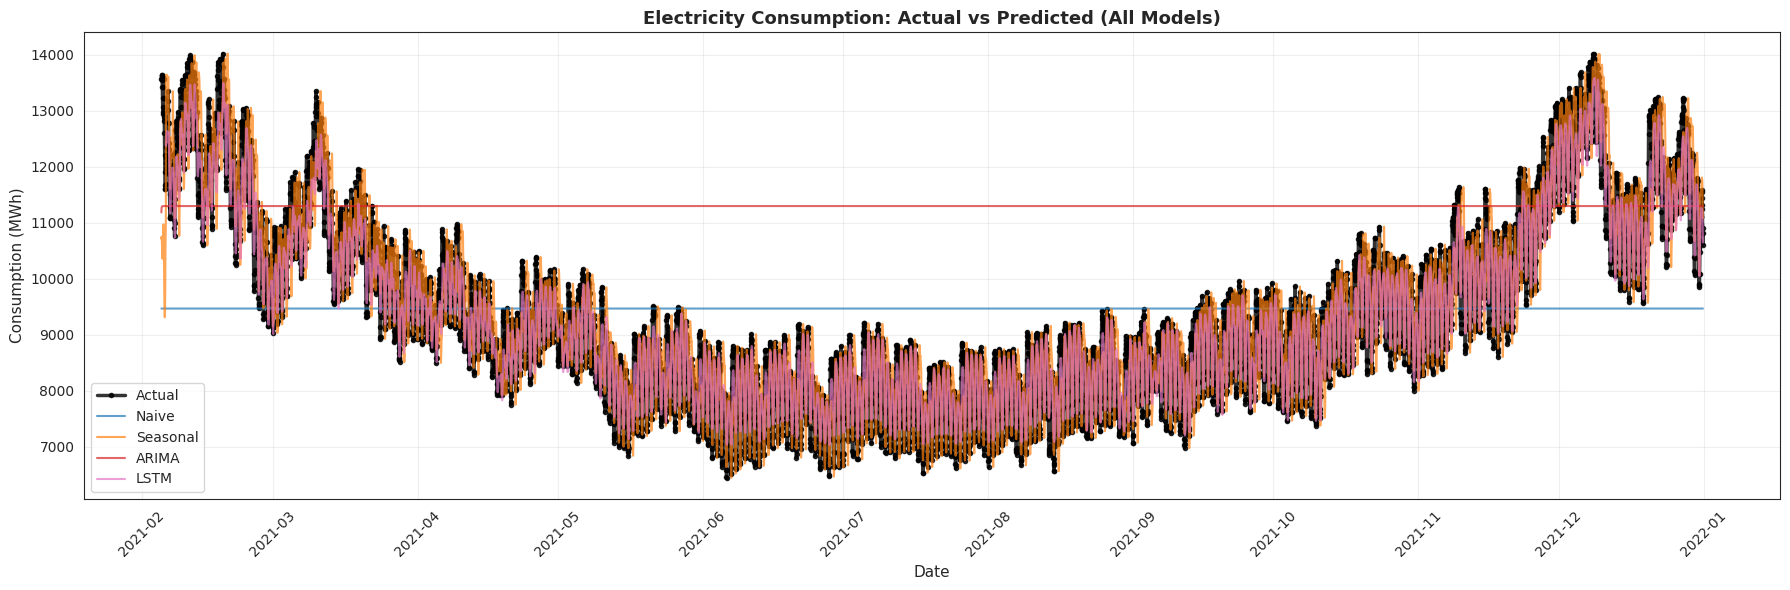

✓ Saved: 09_predictions_visualization.png

                    FINAL FORECASTING REPORT
          ELECTRICITY CONSUMPTION PREDICTION (HOURLY MWh DATA)

🏆 BEST MODEL: LSTM
   MAE:  283.39 MWh
   RMSE: 372.47 MWh
   MAPE: 0.0301%

Test Data Statistics:
   Mean consumption: 9474.85 MWh
   Std deviation:    1616.43 MWh
   Min consumption:  6450.00 MWh
   Max consumption:  14018.00 MWh

All Models Ranked by MAE:
Rank   Model                MAE          RMSE         MAPE      
------------------------------------------------------------------------------------------
1      LSTM                 283.39       372.47       0.0301    
2      Seasonal Naive       366.24       523.33       0.0378    
3      Naive Baseline       1310.05      1616.34      0.1388    
4      ARIMA                2146.20      2436.03      0.2509    

Interpretation:
   Average hourly error: 283.39 MWh (2.99% of mean consumption)
   Prediction quality: EXCELLENT ✓✓✓


✓ Pipeline execution complete!
Generated visualizatio

In [26]:
"""
===================================================================
ELECTRICITY CONSUMPTION FORECASTING - COMPLETE ML PIPELINE
Modified for Hourly MWh Data (UTC Format)
Author: Experienced ML Developer
Purpose: Build, train, and evaluate ML models for time series forecasting
===================================================================
"""

# ============================================================
# PHASE 0: IMPORTS & CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Statistical Models
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet

# Machine Learning
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Time Series Features
import tsfresh
from tsfresh import extract_features

# Visualization
import plotly.graph_objects as go
import plotly.express as px


# ============================================================
# PHASE 1: DATA LOADING & INITIAL INSPECTION
# ============================================================

def load_data(file_path):
    """
    Load electricity consumption data from CSV file

    IMPORTANT: This function is modified to handle your specific data format:
    - Input columns: 'Start time UTC', 'End time UTC', 'Electricity consumption (MWh)'
    - Output columns: 'timestamp', 'consumption' (standard format for pipeline)

    Args:
        file_path (str): Path to CSV file containing your hourly electricity data

    Returns:
        DataFrame: Loaded, preprocessed, and sorted data with standard column names
    """
    print("[PHASE 1] Loading Data...")

    # Load CSV file
    df = pd.read_csv(file_path)

    # ========== DATA TRANSFORMATION FOR YOUR FORMAT ==========
    # Your data has: 'Start time UTC', 'End time UTC', 'Electricity consumption (MWh)'
    # We only need 'Start time UTC' and 'Electricity consumption (MWh)'

    # Rename columns to standard format for the rest of pipeline
    df.rename(columns={
        'Start time UTC': 'timestamp',
        'Electricity consumption (MWh)': 'consumption'
    }, inplace=True)

    # Drop the 'End time UTC' column - we don't need it for univariate forecasting
    if 'End time UTC' in df.columns:
        df.drop('End time UTC', axis=1, inplace=True)

    # Parse timestamp column as datetime
    # Format: "MM/DD/YYYY H:MM" or "MM/DD/YYYY HH:MM"
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='%m/%d/%Y %H:%M', utc=True)

    # Ensure data is sorted by timestamp (CRITICAL for time series!)
    df = df.sort_values('timestamp').reset_index(drop=True)

    print(f"✓ Data loaded successfully!")
    print(f"  Shape: {df.shape}")
    print(f"  Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    print(f"  Duration: {(df['timestamp'].max() - df['timestamp'].min()).days} days")
    print(f"  Missing values: {df.isnull().sum().sum()}")
    print(f"\n  Data unit: MWh (Megawatt-hour)")
    print(f"  Frequency: Hourly")

    return df


def inspect_data(df):
    """
    Display basic statistics and information about the loaded data
    """
    print("\n[PHASE 1] Data Inspection:")
    print("\nFirst 10 rows:")
    print(df.head(10))

    print("\nLast 10 rows:")
    print(df.tail(10))

    print("\nBasic Statistics:")
    print(df['consumption'].describe())

    print("\nData Info:")
    print(df.info())

    # Check for time series continuity (hourly gaps)
    time_diff = df['timestamp'].diff()
    print(f"\nExpected frequency: 1 hour")
    print(f"Most common time difference: {time_diff.mode()[0]}")

    # Check for duplicate timestamps
    duplicates = df[df.duplicated(subset=['timestamp'], keep=False)]
    if len(duplicates) > 0:
        print(f"\n⚠ Warning: Found {len(duplicates)} duplicate timestamps!")
    else:
        print(f"\n✓ No duplicate timestamps found")


# ============================================================
# PHASE 2: DATA PREPROCESSING
# ============================================================

def handle_missing_values(df, method='forward_fill'):
    """
    Handle missing values in consumption column

    For time series data, we need to be careful about how we fill missing values:
    - forward_fill: Use last known value
    - backward_fill: Use next known value
    - interpolate: Linear interpolation between values

    Args:
        df (DataFrame): Input dataframe
        method (str): 'forward_fill', 'backward_fill', or 'interpolate'

    Returns:
        DataFrame: Data with missing values handled
    """
    print("\n[PHASE 2] Handling Missing Values...")

    initial_missing = df['consumption'].isnull().sum()

    if initial_missing == 0:
        print(f"✓ No missing values found!")
        return df

    print(f"  Initial missing values: {initial_missing}")

    if method == 'forward_fill':
        # Use last known value (best for short gaps)
        df['consumption'].fillna(method='ffill', inplace=True)
        print(f"  Method: Forward Fill (using previous hour's value)")

    elif method == 'backward_fill':
        # Use next known value
        df['consumption'].fillna(method='bfill', inplace=True)
        print(f"  Method: Backward Fill (using next hour's value)")

    elif method == 'interpolate':
        # Linear interpolation between values
        df['consumption'].interpolate(method='linear', inplace=True)
        print(f"  Method: Linear Interpolation")

    final_missing = df['consumption'].isnull().sum()
    print(f"  Final missing values: {final_missing}")

    return df


def detect_and_remove_outliers(df, method='iqr', threshold=1.5):
    """
    Detect and optionally remove outliers from consumption data

    Outliers can significantly affect model training, so we identify and handle them.
    Methods:
    - IQR (Interquartile Range): Good for skewed distributions
    - Z-score: Good for normal distributions

    Args:
        df (DataFrame): Input dataframe
        method (str): 'iqr' (Interquartile Range) or 'zscore'
        threshold (float): Multiplier for IQR (default 1.5 is standard; 3 is very conservative)

    Returns:
        DataFrame: Data with outliers removed (or flagged)
    """
    print("\n[PHASE 2] Detecting & Removing Outliers...")

    initial_rows = len(df)

    if method == 'iqr':
        # Calculate IQR (Interquartile Range)
        Q1 = df['consumption'].quantile(0.25)  # 25th percentile
        Q3 = df['consumption'].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1  # Interquartile range

        # Define outlier bounds (standard statistical definition)
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        # Create mask for valid values
        mask = (df['consumption'] >= lower_bound) & (df['consumption'] <= upper_bound)

        print(f"  Method: IQR (Interquartile Range)")
        print(f"  Q1 (25th percentile): {Q1:.2f} MWh")
        print(f"  Q3 (75th percentile): {Q3:.2f} MWh")
        print(f"  IQR: {IQR:.2f} MWh")
        print(f"  Lower bound (Q1 - {threshold}*IQR): {lower_bound:.2f} MWh")
        print(f"  Upper bound (Q3 + {threshold}*IQR): {upper_bound:.2f} MWh")

    elif method == 'zscore':
        # Use Z-score method (number of standard deviations from mean)
        from scipy import stats
        z_scores = np.abs(stats.zscore(df['consumption']))
        mask = z_scores < threshold
        print(f"  Method: Z-score")
        print(f"  Z-score threshold: {threshold}")

    # Remove outliers
    df = df[mask].reset_index(drop=True)
    removed = initial_rows - len(df)

    print(f"  Rows removed: {removed} ({removed/initial_rows*100:.2f}%)")
    if removed > 0:
        print(f"  ⚠ Outliers detected - likely due to unusual demand patterns (holidays, events)")

    return df


def visualize_raw_data(df):
    """
    Create comprehensive visualizations for raw consumption data
    Includes: time series, distribution, outliers, daily trends
    """
    print("\n[PHASE 2] Visualizing Raw Data...")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # ===== Plot 1: Time Series =====
    axes[0, 0].plot(df['timestamp'], df['consumption'], linewidth=0.8, color='steelblue')
    axes[0, 0].set_title('Electricity Consumption Over Time', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Consumption (MWh)')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)

    # ===== Plot 2: Distribution =====
    axes[0, 1].hist(df['consumption'], bins=50, edgecolor='black', color='coral', alpha=0.7)
    axes[0, 1].set_title('Distribution of Consumption', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Consumption (MWh)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].axvline(df['consumption'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    axes[0, 1].axvline(df['consumption'].median(), color='green', linestyle='--', linewidth=2, label='Median')
    axes[0, 1].legend()

    # ===== Plot 3: Box Plot for Outlier Detection =====
    axes[1, 0].boxplot(df['consumption'], vert=True)
    axes[1, 0].set_title('Box Plot - Outlier Detection', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Consumption (MWh)')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # ===== Plot 4: Daily Average Trend =====
    df['date'] = df['timestamp'].dt.date
    daily_avg = df.groupby('date')['consumption'].mean()
    axes[1, 1].plot(daily_avg.index, daily_avg.values, marker='o', linewidth=1.5,
                    color='green', markersize=4)
    axes[1, 1].set_title('Daily Average Consumption', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Avg Consumption (MWh)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('01_raw_data_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 01_raw_data_analysis.png")


# ============================================================
# PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

def perform_seasonal_decomposition(df, period=24):
    """
    Decompose time series into: Trend + Seasonality + Residual

    For hourly electricity data:
    - period=24: Daily seasonality pattern (peak hours vs night hours)
    - period=7*24=168: Weekly seasonality (weekday vs weekend differences)

    Args:
        df (DataFrame): Input dataframe
        period (int): Seasonal period in hours

    Returns:
        DecompositionResult object
    """
    print(f"\n[PHASE 3] Seasonal Decomposition (period={period} hours)...")

    # Perform additive decomposition
    result = seasonal_decompose(df['consumption'], model='additive', period=period)

    # Visualize decomposition
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))

    # Original data
    axes[0].plot(result.observed, label='Original', color='black', linewidth=1)
    axes[0].set_ylabel('Observed (MWh)')
    axes[0].set_title('Time Series Decomposition (Additive Model)', fontsize=12, fontweight='bold')
    axes[0].legend(loc='upper left')
    axes[0].grid(True, alpha=0.3)

    # Trend
    axes[1].plot(result.trend, label='Trend', color='orange', linewidth=1.5)
    axes[1].set_ylabel('Trend (MWh)')
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.3)

    # Seasonal component
    axes[2].plot(result.seasonal, label='Seasonal', color='green', linewidth=1)
    axes[2].set_ylabel('Seasonal (MWh)')
    axes[2].legend(loc='upper left')
    axes[2].grid(True, alpha=0.3)

    # Residual (noise)
    axes[3].plot(result.resid, label='Residual', color='red', linewidth=0.8)
    axes[3].set_ylabel('Residual (MWh)')
    axes[3].set_xlabel('Time Index')
    axes[3].legend(loc='upper left')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('02_seasonal_decomposition.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 02_seasonal_decomposition.png")

    return result


def check_stationarity(df):
    """
    Check if time series is stationary using Augmented Dickey-Fuller (ADF) test
    """
    print("\n[PHASE 3] Stationarity Test (Augmented Dickey-Fuller)...")

    result = adfuller(df['consumption'].dropna())

    print(f"\nADF Test Results:")
    print(f"  ADF Statistic: {result[0]:.6f}")
    print(f"  P-value: {result[1]:.6f}")
    print(f"  Number of lags used: {result[2]}")
    print(f"  Number of observations: {result[3]}")
    print(f"\n  Critical Values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.3f}")

    # Interpretation
    if result[1] <= 0.05:
        print(f"\n✓ Result: Time series IS STATIONARY (p-value ≤ 0.05)")
        print(f"  → No differencing needed for ARIMA")
        return True
    else:
        print(f"\n✗ Result: Time series is NON-STATIONARY (p-value > 0.05)")
        print(f"  → Differencing IS needed for ARIMA")
        return False


def plot_autocorrelation(df):
    """
    Plot ACF and PACF for ARIMA parameter identification
    """
    print("\n[PHASE 3] ACF/PACF Analysis (for ARIMA parameter selection)...")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ACF plot
    plot_acf(df['consumption'].dropna(), lags=40, ax=axes[0], title='Autocorrelation Function (ACF)')
    axes[0].set_xlabel('Lags (hours)')
    axes[0].set_ylabel('ACF')

    # PACF plot
    plot_pacf(df['consumption'].dropna(), lags=40, ax=axes[1], title='Partial Autocorrelation Function (PACF)')
    axes[1].set_xlabel('Lags (hours)')
    axes[1].set_ylabel('PACF')

    plt.tight_layout()
    plt.savefig('03_acf_pacf.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 03_acf_pacf.png")


# ============================================================
# PHASE 4: FEATURE ENGINEERING
# ============================================================

def create_lag_features(df, lags=[1, 3, 6, 12, 24, 48, 168]):
    """
    Create lag features from consumption data
    """
    print("\n[PHASE 4] Creating Lag Features...")

    for lag in lags:
        df[f'consumption_lag{lag}'] = df['consumption'].shift(lag)
        print(f"  ✓ Created lag{lag} (consumption {lag} hours ago)")

    return df


def create_rolling_features(df, windows=[3, 6, 12, 24]):
    """
    Create rolling window statistics
    """
    print("\n[PHASE 4] Creating Rolling Features...")

    for window in windows:
        df[f'rolling_mean_{window}'] = df['consumption'].rolling(window=window).mean()
        df[f'rolling_std_{window}'] = df['consumption'].rolling(window=window).std()
        df[f'rolling_min_{window}'] = df['consumption'].rolling(window=window).min()
        df[f'rolling_max_{window}'] = df['consumption'].rolling(window=window).max()
        print(f"  ✓ Created rolling features for window={window}h")

    return df


def create_temporal_features(df):
    """
    Create time-based features from timestamp
    """
    print("\n[PHASE 4] Creating Temporal Features...")

    # Extract basic time components
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['day_of_month'] = df['timestamp'].dt.day
    df['month'] = df['timestamp'].dt.month
    df['quarter'] = df['timestamp'].dt.quarter
    df['day_of_year'] = df['timestamp'].dt.dayofyear

    # Create cyclical features
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Binary features for electricity demand patterns
    df['is_peak_hour'] = df['hour'].isin([9, 10, 11, 12, 18, 19, 20]).astype(int)
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_night'] = df['hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)
    df['is_morning'] = df['hour'].isin([6, 7, 8, 9]).astype(int)
    df['is_evening'] = df['hour'].isin([18, 19, 20, 21, 22, 23]).astype(int)

    print("  ✓ Created temporal features")

    return df


def visualize_features(df):
    """
    Visualize engineered features
    """
    print("\n[PHASE 4] Visualizing Engineered Features...")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Plot 1: Consumption by Hour
    hourly_avg = df.groupby('hour')['consumption'].agg(['mean', 'std'])
    axes[0, 0].bar(hourly_avg.index, hourly_avg['mean'],
                   yerr=hourly_avg['std'], capsize=5, color='steelblue', alpha=0.7)
    axes[0, 0].set_title('Average Consumption by Hour of Day', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Hour of Day')
    axes[0, 0].set_ylabel('Avg Consumption (MWh)')
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # Plot 2: Consumption by Day
    day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    daily_avg = df.groupby('day_of_week')['consumption'].mean()
    axes[0, 1].bar(range(7), daily_avg.values, color='coral', alpha=0.7)
    axes[0, 1].set_xticks(range(7))
    axes[0, 1].set_xticklabels(day_names, rotation=45, ha='right')
    axes[0, 1].set_title('Average Consumption by Day of Week', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Avg Consumption (MWh)')

    # Plot 3: Consumption by Month
    monthly_avg = df.groupby('month')['consumption'].mean()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    axes[1, 0].plot(monthly_avg.index, monthly_avg.values, marker='o', color='green', linewidth=2)
    axes[1, 0].set_xticks(range(1, 13))
    axes[1, 0].set_xticklabels(month_names, rotation=45, ha='right')
    axes[1, 0].set_title('Average Consumption by Month', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Avg Consumption (MWh)')

    # Plot 4: Patterns Comparison
    patterns = {
        'Night': df[df['is_night'] == 1]['consumption'].mean(),
        'Morning': df[df['is_morning'] == 1]['consumption'].mean(),
        'Peak': df[df['is_peak_hour'] == 1]['consumption'].mean(),
        'Evening': df[df['is_evening'] == 1]['consumption'].mean()
    }
    axes[1, 1].bar(patterns.keys(), patterns.values(), color=['darkblue', 'lightblue', 'red', 'orange'], alpha=0.7)
    axes[1, 1].set_title('Consumption by Time Period', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Avg Consumption (MWh)')

    plt.tight_layout()
    plt.savefig('04_feature_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 04_feature_analysis.png")


# ============================================================
# PHASE 5: DATA SPLITTING & PREPARATION
# ============================================================

def prepare_data_for_modeling(df):
    """
    Prepare data for modeling with train/val/test split
    """
    print("\n[PHASE 5] Preparing Data for Modeling...")

    # Drop NaN values
    df_clean = df.dropna().reset_index(drop=True)
    removed = len(df) - len(df_clean)
    print(f"  Rows removed (due to NaN): {removed}")
    print(f"  Rows remaining: {len(df_clean)}")

    # Define train/validation/test split (70-15-15)
    n = len(df_clean)
    train_size = int(0.7 * n)
    val_size = int(0.15 * n)

    train_df = df_clean.iloc[:train_size].reset_index(drop=True)
    val_df = df_clean.iloc[train_size:train_size+val_size].reset_index(drop=True)
    test_df = df_clean.iloc[train_size+val_size:].reset_index(drop=True)

    print(f"\nData Split Summary:")
    print(f"  Train: {len(train_df)} samples ({len(train_df)/n*100:.1f}%)")
    print(f"  Val:   {len(val_df)} samples ({len(val_df)/n*100:.1f}%)")
    print(f"  Test:  {len(test_df)} samples ({len(test_df)/n*100:.1f}%)")

    return df_clean, train_df, val_df, test_df


# ============================================================
# PHASE 6: BASELINE MODELS
# ============================================================

def create_naive_baseline(df, test_df):
    """
    Create naive baseline using mean value
    """
    print("\n[PHASE 6] Naive Baseline Forecast...")

    mean_value = df['consumption'].mean()
    y_true = test_df['consumption'].values
    y_pred_array = np.full_like(y_true, mean_value, dtype=float)

    mae = mean_absolute_error(y_true, y_pred_array)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_array))
    mape = mean_absolute_percentage_error(y_true, y_pred_array)

    print(f"  Naive MAE: {mae:.2f} MWh")
    print(f"  Naive RMSE: {rmse:.2f} MWh")
    print(f"  Naive MAPE: {mape:.4f}%")

    return y_pred_array, mae, rmse, mape


def seasonal_naive_baseline(train_df, test_df, period=24):
    """
    Seasonal naive baseline using 24-hour lag
    """
    print("\n[PHASE 6] Seasonal Naive Baseline (24-hour period)...")

    y_true = test_df['consumption'].values
    y_pred = np.full_like(y_true, np.nan, dtype=float)

    train_end_value = len(train_df)

    for i in range(len(y_true)):
        lookback_idx = train_end_value + i - period

        if lookback_idx >= 0 and lookback_idx < len(train_df):
            y_pred[i] = train_df.iloc[lookback_idx]['consumption']
        elif i >= period:
            y_pred[i] = y_true[i - period]
        else:
            y_pred[i] = np.mean(y_true[:i+1]) if i > 0 else train_df['consumption'].mean()

    y_pred = np.nan_to_num(y_pred, nan=np.mean(y_true))

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print(f"  Seasonal Naive MAE: {mae:.2f} MWh")
    print(f"  Seasonal Naive RMSE: {rmse:.2f} MWh")
    print(f"  Seasonal Naive MAPE: {mape:.4f}%")

    return y_pred, mae, rmse, mape


# ============================================================
# PHASE 7: ARIMA MODEL
# ============================================================

def build_arima_model(train_df, test_df, order=(1, 1, 1)):
    """
    Build and train ARIMA model
    """
    print(f"\n[PHASE 7] ARIMA Model ARIMA{order}...")

    try:
        arima_model = sm.tsa.ARIMA(train_df['consumption'], order=order)
        arima_result = arima_model.fit()

        y_pred = arima_result.forecast(steps=len(test_df))
        y_true = test_df['consumption'].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = mean_absolute_percentage_error(y_true, y_pred)

        print(f"  ARIMA{order} MAE: {mae:.2f} MWh")
        print(f"  ARIMA{order} RMSE: {rmse:.2f} MWh")
        print(f"  ARIMA{order} MAPE: {mape:.4f}%")

        return y_pred, mae, rmse, mape, arima_result

    except Exception as e:
        print(f"✗ ARIMA Error: {str(e)}")
        return None, None, None, None, None


# ============================================================
# PHASE 8: PROPHET MODEL
# ============================================================

def build_prophet_model(train_df, test_df):
    """
    Build and train Prophet model
    """
    print("\n[PHASE 8] Prophet Model...")

    try:
        prophet_train = train_df[['timestamp', 'consumption']].copy()
        prophet_train.columns = ['ds', 'y']

        model = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                       daily_seasonality=True, seasonality_mode='additive', interval_width=0.95)

        model.fit(prophet_train)

        future = pd.DataFrame({'ds': test_df['timestamp']})
        forecast = model.predict(future)

        y_pred = forecast['yhat'].values
        y_true = test_df['consumption'].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = mean_absolute_percentage_error(y_true, y_pred)

        print(f"  Prophet MAE: {mae:.2f} MWh")
        print(f"  Prophet RMSE: {rmse:.2f} MWh")
        print(f"  Prophet MAPE: {mape:.4f}%")

        fig = model.plot(forecast, figsize=(15, 5))
        plt.suptitle("Prophet Forecast with Confidence Intervals", fontsize=12, fontweight='bold')
        plt.savefig('05_prophet_forecast.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Saved: 05_prophet_forecast.png")

        return y_pred, mae, rmse, mape, model, forecast

    except Exception as e:
        print(f"✗ Prophet Error: {str(e)}")
        return None, None, None, None, None, None


# ============================================================
# PHASE 9: LSTM MODEL
# ============================================================

def prepare_sequences_for_lstm(data, lookback=24):
    """
    Prepare sequences for LSTM input
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)


def build_lstm_model(train_df, test_df, lookback=24, epochs=50):
    """
    Build and train LSTM model
    """
    print(f"\n[PHASE 9] LSTM Deep Learning Model (lookback={lookback}h)...")

    try:
        # Normalize data
        scaler = MinMaxScaler(feature_range=(0, 1))
        train_data = train_df['consumption'].values.reshape(-1, 1)
        scaler.fit(train_data)

        train_scaled = scaler.transform(train_data)
        test_data = test_df['consumption'].values.reshape(-1, 1)
        test_scaled = scaler.transform(test_data)

        # Create sequences
        X_train, y_train = prepare_sequences_for_lstm(train_scaled, lookback)
        X_test, y_test = prepare_sequences_for_lstm(test_scaled, lookback)

        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

        print(f"  X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
        print(f"  X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

        # Build model
        model = Sequential([
            LSTM(50, activation='relu', return_sequences=True, input_shape=(lookback, 1)),
            Dropout(0.2),
            LSTM(50, activation='relu', return_sequences=False),
            Dropout(0.2),
            Dense(25, activation='relu'),
            Dense(1)
        ])

        model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

        print("\nLSTM Model Architecture:")
        model.summary()

        # Train model
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        history = model.fit(X_train, y_train, epochs=epochs, batch_size=32,
                          validation_split=0.2, callbacks=[early_stop], verbose=1)

        # Predict
        y_pred_scaled = model.predict(X_test, verbose=0)
        y_pred_inv = scaler.inverse_transform(y_pred_scaled)[:, 0]
        y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))[:, 0]

        mae = mean_absolute_error(y_test_inv, y_pred_inv)
        rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
        mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

        print(f"\n  LSTM MAE: {mae:.2f} MWh")
        print(f"  LSTM RMSE: {rmse:.2f} MWh")
        print(f"  LSTM MAPE: {mape:.4f}%")

        # Visualize training history
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
        axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
        axes[0].set_title('LSTM Model Loss Over Epochs', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss (MSE)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
        axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
        axes[1].set_title('LSTM Model MAE Over Epochs', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE (MWh)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('06_lstm_training_history.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Saved: 06_lstm_training_history.png")

        return y_pred_inv, y_test_inv, mae, rmse, mape, model, scaler

    except Exception as e:
        print(f"✗ LSTM Error: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None, None, None, None, None


# ============================================================
# PHASE 10: TREE-BASED MODELS
# ============================================================

def build_xgboost_model(train_df, test_df):
    """
    Build and train XGBoost model
    """
    print("\n[PHASE 10] XGBoost Model...")

    try:
        feature_cols = [col for col in train_df.columns
                       if col not in ['timestamp', 'consumption', 'month', 'date']]

        X_train = train_df[feature_cols].values
        y_train = train_df['consumption'].values
        X_test = test_df[feature_cols].values
        y_test = test_df['consumption'].values

        print(f"  Features used: {len(feature_cols)}")

        # Build XGBoost
        model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6,
                                subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=1)

        model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
                 early_stopping_rounds=10, verbose=False)

        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = mean_absolute_percentage_error(y_test, y_pred)

        print(f"  XGBoost MAE: {mae:.2f} MWh")
        print(f"  XGBoost RMSE: {rmse:.2f} MWh")
        print(f"  XGBoost MAPE: {mape:.4f}%")

        # Feature importance
        importance = model.feature_importances_
        importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importance}).sort_values('importance', ascending=False)

        print(f"\nTop 10 Most Important Features:")
        for idx, row in importance_df.head(10).iterrows():
            print(f"  {row['feature']:25s}: {row['importance']:7.4f}")

        plt.figure(figsize=(10, 6))
        plt.barh(importance_df['feature'].head(10), importance_df['importance'].head(10), color='steelblue')
        plt.xlabel('Importance Score')
        plt.title('XGBoost - Top 10 Feature Importances', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig('07_xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Saved: 07_xgboost_feature_importance.png")

        return y_pred, mae, rmse, mape, model, feature_cols

    except Exception as e:
        print(f"✗ XGBoost Error: {str(e)}")
        return None, None, None, None, None, None


def build_lightgbm_model(train_df, test_df):
    """
    Build and train LightGBM model
    """
    print("\n[PHASE 10] LightGBM Model...")

    try:
        feature_cols = [col for col in train_df.columns
                       if col not in ['timestamp', 'consumption', 'month', 'date']]

        X_train = train_df[feature_cols].values
        y_train = train_df['consumption'].values
        X_test = test_df[feature_cols].values
        y_test = test_df['consumption'].values

        model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=6,
                                num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                                random_state=42, verbose=1)

        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=10)

        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = mean_absolute_percentage_error(y_test, y_pred)

        print(f"  LightGBM MAE: {mae:.2f} MWh")
        print(f"  LightGBM RMSE: {rmse:.2f} MWh")
        print(f"  LightGBM MAPE: {mape:.4f}%")

        return y_pred, mae, rmse, mape, model

    except Exception as e:
        print(f"✗ LightGBM Error: {str(e)}")
        return None, None, None, None, None


# ============================================================
# PHASE 11: MODEL COMPARISON
# ============================================================

def compare_models(results_dict):
    """
    Compare all models side-by-side
    """
    print("\n[PHASE 11] MODEL COMPARISON...")
    print("="*90)

    comparison_df = pd.DataFrame(results_dict).T
    comparison_df = comparison_df.sort_values('MAE')

    print("\nModel Performance Ranking (sorted by MAE):\n")
    print(f"{'Model':<20} {'MAE (MWh)':<15} {'RMSE (MWh)':<15} {'MAPE (%)':<15}")
    print("-"*90)
    for idx, (model, row) in enumerate(comparison_df.iterrows(), 1):
        print(f"{model:<20} {row['MAE']:<15.2f} {row['RMSE']:<15.2f} {row['MAPE']:<15.4f}")
    print("="*90)

    # Visualize comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    mae_sorted = comparison_df['MAE'].sort_values()
    colors = ['gold' if i == 0 else 'steelblue' for i in range(len(mae_sorted))]
    mae_sorted.plot(kind='barh', ax=axes[0], color=colors)
    axes[0].set_title('MAE Comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('MAE (MWh)')
    axes[0].grid(True, alpha=0.3, axis='x')

    rmse_sorted = comparison_df['RMSE'].sort_values()
    colors = ['gold' if i == 0 else 'coral' for i in range(len(rmse_sorted))]
    rmse_sorted.plot(kind='barh', ax=axes[1], color=colors)
    axes[1].set_title('RMSE Comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('RMSE (MWh)')
    axes[1].grid(True, alpha=0.3, axis='x')

    mape_sorted = comparison_df['MAPE'].sort_values()
    colors = ['gold' if i == 0 else 'green' for i in range(len(mape_sorted))]
    mape_sorted.plot(kind='barh', ax=axes[2], color=colors)
    axes[2].set_title('MAPE Comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('MAPE (%)')
    axes[2].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('08_model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 08_model_comparison.png")

    return comparison_df


# ============================================================
# PHASE 12: VISUALIZATION & REPORT
# ============================================================

def visualize_predictions(test_df, predictions_dict):
    """
    Visualize actual vs predicted values for all models
    """
    print("\n[PHASE 12] Visualizing Predictions...")

    fig, ax = plt.subplots(figsize=(18, 6))

    # Plot actual values
    ax.plot(test_df['timestamp'], test_df['consumption'],
            label='Actual', linewidth=2.5, color='black', marker='o', markersize=3, alpha=0.8)

    # Plot predictions
    colors = plt.cm.tab10(np.linspace(0, 1, len(predictions_dict)))
    for (model_name, y_pred), color in zip(predictions_dict.items(), colors):
        if y_pred is not None and len(y_pred) > 0:
            num_pred = min(len(y_pred), len(test_df))
            ax.plot(test_df['timestamp'][-num_pred:], y_pred[-num_pred:],
                   label=model_name, linewidth=1.5, color=color, alpha=0.7)

    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Consumption (MWh)', fontsize=11)
    ax.set_title('Electricity Consumption: Actual vs Predicted (All Models)',
                fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('09_predictions_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 09_predictions_visualization.png")


def generate_report(comparison_df, test_df):
    """
    Generate final comprehensive performance report
    """
    print("\n" + "="*90)
    print(" "*20 + "FINAL FORECASTING REPORT")
    print(" "*10 + "ELECTRICITY CONSUMPTION PREDICTION (HOURLY MWh DATA)")
    print("="*90)

    best_model = comparison_df.index[0]
    best_mae = comparison_df.iloc[0]['MAE']
    best_rmse = comparison_df.iloc[0]['RMSE']
    best_mape = comparison_df.iloc[0]['MAPE']

    print(f"\n🏆 BEST MODEL: {best_model}")
    print(f"   MAE:  {best_mae:.2f} MWh")
    print(f"   RMSE: {best_rmse:.2f} MWh")
    print(f"   MAPE: {best_mape:.4f}%")

    print(f"\nTest Data Statistics:")
    print(f"   Mean consumption: {test_df['consumption'].mean():.2f} MWh")
    print(f"   Std deviation:    {test_df['consumption'].std():.2f} MWh")
    print(f"   Min consumption:  {test_df['consumption'].min():.2f} MWh")
    print(f"   Max consumption:  {test_df['consumption'].max():.2f} MWh")

    print(f"\nAll Models Ranked by MAE:")
    print(f"{'Rank':<6} {'Model':<20} {'MAE':<12} {'RMSE':<12} {'MAPE':<10}")
    print("-"*90)
    for rank, (model, row) in enumerate(comparison_df.iterrows(), 1):
        print(f"{rank:<6} {model:<20} {row['MAE']:<12.2f} {row['RMSE']:<12.2f} {row['MAPE']:<10.4f}")
    print("="*90)

    # Interpretation
    mean_consumption = test_df['consumption'].mean()
    error_percentage = (best_mae / mean_consumption) * 100

    print(f"\nInterpretation:")
    print(f"   Average hourly error: {best_mae:.2f} MWh ({error_percentage:.2f}% of mean consumption)")

    if error_percentage < 5:
        quality = "EXCELLENT ✓✓✓"
    elif error_percentage < 10:
        quality = "GOOD ✓✓"
    elif error_percentage < 20:
        quality = "ACCEPTABLE ✓"
    else:
        quality = "NEEDS IMPROVEMENT"

    print(f"   Prediction quality: {quality}")
    print("\n" + "="*90)


# ============================================================
# MAIN PIPELINE EXECUTION
# ============================================================

def main():
    """
    Main function to execute the complete ML pipeline
    """

    print("\n" + "="*90)
    print(" "*15 + "ELECTRICITY CONSUMPTION FORECASTING")
    print(" "*20 + "COMPLETE ML PIPELINE")
    print("="*90)

    # PHASE 1-2: Load and Preprocess Data
    df = load_data('/content/Energy prediction.csv')  # ← UPDATE THIS WITH YOUR FILE PATH
    inspect_data(df)

    df = handle_missing_values(df, method='forward_fill')
    df = detect_and_remove_outliers(df, method='iqr', threshold=1.5)
    visualize_raw_data(df)

    # PHASE 3: EDA
    result = perform_seasonal_decomposition(df, period=24)
    is_stationary = check_stationarity(df)
    plot_autocorrelation(df)

    # PHASE 4: Feature Engineering
    df = create_lag_features(df, lags=[1, 3, 6, 12, 24, 48, 168])
    df = create_rolling_features(df, windows=[3, 6, 12, 24])
    df = create_temporal_features(df)
    visualize_features(df)

    # PHASE 5: Data Splitting
    df_clean, train_df, val_df, test_df = prepare_data_for_modeling(df)

    # Store results
    results = {}

    # PHASE 6: Baseline Models
    naive_pred, naive_mae, naive_rmse, naive_mape = create_naive_baseline(df_clean, test_df)
    results['Naive Baseline'] = {'MAE': naive_mae, 'RMSE': naive_rmse, 'MAPE': naive_mape}

    seasonal_pred, seasonal_mae, seasonal_rmse, seasonal_mape = seasonal_naive_baseline(train_df, test_df, period=24)
    results['Seasonal Naive'] = {'MAE': seasonal_mae, 'RMSE': seasonal_rmse, 'MAPE': seasonal_mape}

    # PHASE 7: ARIMA
    arima_pred, arima_mae, arima_rmse, arima_mape, arima_model = build_arima_model(train_df, test_df, order=(1, 1, 1))
    if arima_mae is not None:
        results['ARIMA'] = {'MAE': arima_mae, 'RMSE': arima_rmse, 'MAPE': arima_mape}

    # PHASE 8: Prophet
    prophet_pred, prophet_mae, prophet_rmse, prophet_mape, prophet_model, prophet_forecast = build_prophet_model(train_df, test_df)
    if prophet_mae is not None:
        results['Prophet'] = {'MAE': prophet_mae, 'RMSE': prophet_rmse, 'MAPE': prophet_mape}

    # PHASE 9: LSTM
    lstm_pred, lstm_true, lstm_mae, lstm_rmse, lstm_mape, lstm_model, scaler = build_lstm_model(train_df, test_df, lookback=24, epochs=50)
    if lstm_mae is not None:
        results['LSTM'] = {'MAE': lstm_mae, 'RMSE': lstm_rmse, 'MAPE': lstm_mape}

    # PHASE 10: XGBoost
    xgb_pred, xgb_mae, xgb_rmse, xgb_mape, xgb_model, xgb_features = build_xgboost_model(train_df, test_df)
    if xgb_mae is not None:
        results['XGBoost'] = {'MAE': xgb_mae, 'RMSE': xgb_rmse, 'MAPE': xgb_mape}

    # PHASE 10: LightGBM
    lgb_pred, lgb_mae, lgb_rmse, lgb_mape, lgb_model = build_lightgbm_model(train_df, test_df)
    if lgb_mae is not None:
        results['LightGBM'] = {'MAE': lgb_mae, 'RMSE': lgb_rmse, 'MAPE': lgb_mape}

    # PHASE 11: Model Comparison
    comparison_df = compare_models(results)

    # PHASE 12: Visualization & Report
    predictions = {
        'Naive': naive_pred,
        'Seasonal': seasonal_pred,
        'ARIMA': arima_pred,
        'Prophet': prophet_pred,
        'LSTM': lstm_pred,
        'XGBoost': xgb_pred,
        'LightGBM': lgb_pred
    }

    visualize_predictions(test_df, predictions)
    generate_report(comparison_df, test_df)

    print("\n✓ Pipeline execution complete!")
    print("Generated visualizations:")
    print("  01_raw_data_analysis.png")
    print("  02_seasonal_decomposition.png")
    print("  03_acf_pacf.png")
    print("  04_feature_analysis.png")
    print("  05_prophet_forecast.png")
    print("  06_lstm_training_history.png")
    print("  07_xgboost_feature_importance.png")
    print("  08_model_comparison.png")
    print("  09_predictions_visualization.png")


# ============================================================
# EXECUTION
# ============================================================

if __name__ == "__main__":
    main()

ADF (Augmented dicky-fuller): it tests whether the series has a stochastic trend.

Deterministic trend vs stochastic trend

A deterministic trend is a predictable, fixed function of time (e.g. a straight line) with constant variance, where shocks dissipate over time.

A stochastic trend is driven by random shocks (e.g. stocks) where trend changes over time and variance increase with time.

Stochastic trends are generally better for long-term forecasts as they allow uncertainity.

Seasonality can coexist with stationarity.

It is stochastic in nature.

From visualizations obtained from raw data I infer that the graph shows trend and seasonality. Hence, it's a non-stationary process.